In [ ]:
        # -------Five assumption of Linear Regression----#

# 1. Linear Relation between input and output
# 2. No multicolinearity
# 3. Normality of Residual
# 4. Homoscedasticity
# 5. No autocorrelation of residual or errors

In [ ]:
# Linear Relation
# To perform Linear Regression data should have linear relationship
# Negative or positive correlationship but linear

In [ ]:
# Multicolinearity
# If input features are correlated with each other called multicolinearity
# Input column should be independent from each other

In [ ]:
# Normality of Residual
# It means the residuals/errors follow a normal distribution (bell-shaped distribution).

In [ ]:
# Homoscedasticity
# Means Prediction errors should spread evenly
# Homo=same, dasticity=scatter

In [ ]:
# No Autocorrelation
# Residuals should be independent.

In [1]:
# Code example
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Loading Data
df=pd.read_csv('data.csv')
df.head(3)

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421


In [4]:
# input and output variable extraction
X=df.iloc[:, 0:3]
y=df.iloc[:, -1]

In [5]:
# Train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1)

In [7]:
# Train linear model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
# Predict the model to find residual/error
y_pred=model.predict(X_test)
residual=y_test-y_pred

Text(0.5, 1.0, 'Feature3')

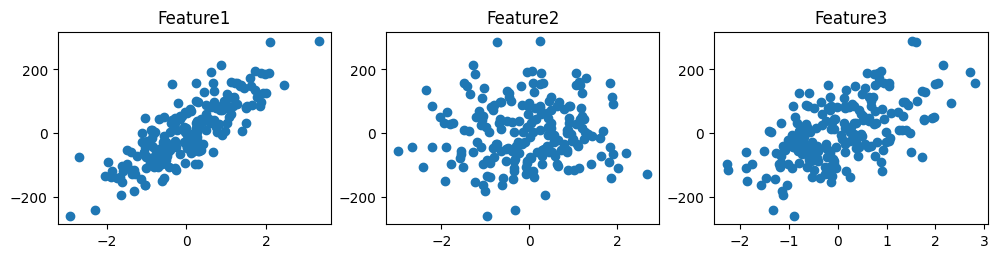

In [ ]:
# Linear Relationship
fig, (axis1, axis2, axis3) = plt.subplots(ncols=3, figsize = (12,2.5) )

axis1.scatter(df['feature1'], df['target'])
axis1.set_title('Feature1')
axis2.scatter(df['feature2'], df['target'])
axis2.set_title('Feature2')
axis3.scatter(df['feature3'], df['target'])
axis3.set_title('Feature3')

In [ ]:
# Data show linear relationship with each other

In [ ]:
# Multicollinearity
# There are two way to find out multicolinearity
    # Correlation metrix
    # Variance Inflation Factor(VIF)

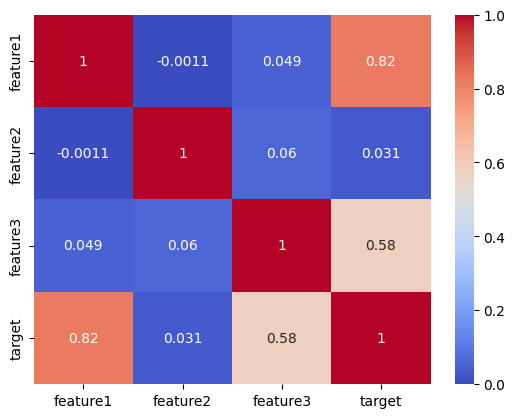

In [19]:
# Correlation Metrix
corr_matrix=df.corr()
# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()


In [21]:
# Vif
# 1	No multicollinearity
# 1–5	Moderate correlation
# >5	High multicollinearity
# >10	Very serious multicollinearity

from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = []

for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train, i))
pd.DataFrame({'vif': vif}, index=df.columns[0:3]).T

,feature1,feature2,feature3
vif,1.010326,1.009871,1.01395


<Axes: xlabel='target', ylabel='Count'>

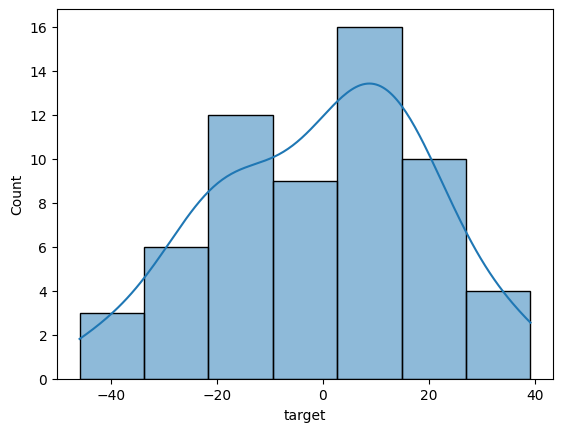

In [25]:
# Normality of Residual
sns.histplot(residual, kde=True)

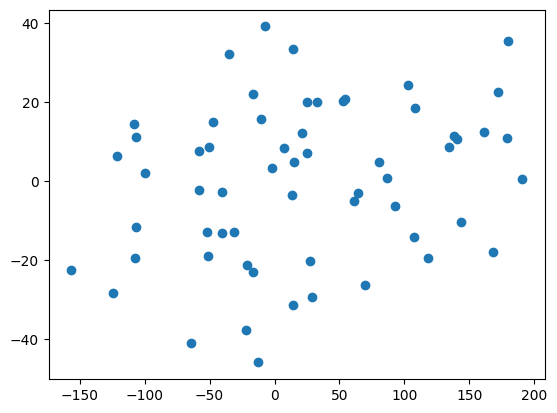

In [26]:
# Homoscedasticity
plt.scatter(y_pred,residual)

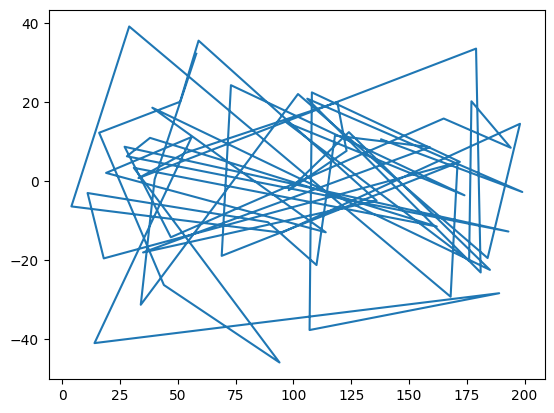

In [28]:
# Autocorrelation of residual
plt.plot(residual)